In [1]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os

range_real = [0, 1, 3, 4, 6, 7, 9, 10, 11, 12, 13]
range_alive = [1, 4, 9, 10, 11, 12, 13]
range_dead = [0, 3, 6, 7]

rp = '/Users/pp/data/Simulations/PHS_GFO'
xd = xr.open_dataset(f"{rp}/Sens_Output_agg.nc")
df = pd.read_csv(f"{rp}/SwissParameterListWide_24_1000000.csv")

if not os.path.isdir(rt_path):
    os.mkdir(rt_path)

In [2]:
cols = np.array(['tab:blue' for _ in range(14)])
cols[0] = 'tab:red'
cols[2] = 'tab:red'
cols[3] = 'tab:red'
cols[6] = 'tab:red'
cols[7] = 'tab:red'

In [3]:
#xd = xr.open_dataset("/Users/pp/data/Simulations/A08_Hydraulics_standalone/Relative_Hypercube_sampling/Sens_Output_6_peak_rm.nc")
#df = pd.read_csv("/Users/pp/data/Simulations/A08_Hydraulics_standalone/Relative_Hypercube_sampling/setups/Full_Parameter_setup_hyperfixed_1000000.csv")
df_rmse = []
for sv in soil_variants:
    df_rmse.append(xr.open_dataset(f"/Users/pp/data/Simulations/A08_Hydraulics_standalone/Relative_Hypercube_sampling/1.2_cond/"+output_path).data_vars['RMSE_swiss_trees'].to_pandas())
df_params = pd.read_csv(f"/Users/pp/data/Simulations/A08_Hydraulics_standalone/Relative_Hypercube_sampling/setups/Full_Parameter_setup_hyperfixed_cond_variable_all_no_psi_stem_H_no_lai_{id}.csv")

In [4]:
cddead_list = []

for vs in range(0, len(soil_variants)):
    for i in range_real:

        ord = df_rmse[vs][i].sort_values(0)[0:10000]
        ind = ord.index.to_numpy()
        df_slice_dead = df_params.iloc[ind]
        df_slice_dead = df_slice_dead.drop(columns = ['Unnamed: 0'])
        df_slice_dead.to_csv(f"{rt_path}/{soil_variants[vs]}_parameters_{i}.csv")
        df_slice_dead['rmse'] = ord
        df_slice_dead.to_csv(f"{rt_path}/{soil_variants[vs]}_parameters_{i}_rmse.csv")


    alive_err = df_rmse[vs][range_alive].sum(axis =1)
    ord = alive_err.sort_values(0)[0:10000]
    ind = ord.index.to_numpy()
    df_slice = df_params.iloc[ind]
    df_slice = df_slice.drop(columns = ['Unnamed: 0'])
    df_slice.to_csv(f"{rt_path}/{soil_variants[vs]}_params_all_alive.csv")
    df_slice['rmse'] = ord
    df_slice.to_csv(f"{rt_path}/{soil_variants[vs]}_params_all_alive_rmse.csv")

/var/folders/9r/97b9zk_j4ys8v5lnksc4l4j00000gq/T/ipykernel_34902/2352743033.py:6: FutureWarning: In a future version of pandas all arguments of Series.sort_values will be keyword-only.
  ord = df_rmse[vs][i].sort_values(0)[0:10000]
/var/folders/9r/97b9zk_j4ys8v5lnksc4l4j00000gq/T/ipykernel_34902/2352743033.py:6: FutureWarning: In a future version of pandas all arguments of Series.sort_values will be keyword-only.
  ord = df_rmse[vs][i].sort_values(0)[0:10000]
/var/folders/9r/97b9zk_j4ys8v5lnksc4l4j00000gq/T/ipykernel_34902/2352743033.py:6: FutureWarning: In a future version of pandas all arguments of Series.sort_values will be keyword-only.
  ord = df_rmse[vs][i].sort_values(0)[0:10000]
/var/folders/9r/97b9zk_j4ys8v5lnksc4l4j00000gq/T/ipykernel_34902/2352743033.py:6: FutureWarning: In a future version of pandas all arguments of Series.sort_values will be keyword-only.
  ord = df_rmse[vs][i].sort_values(0)[0:10000]
/var/folders/9r/97b9zk_j4ys8v5lnksc4l4j00000gq/T/ipykernel_34902/2352743

In [5]:
from enum import Enum
import sys
sys.path.append('/Users/pp/Documents/Repos/hydro_standalone/cmake-build-release')

from hydro_standalone import Simulation_Multi
from hydro_standalone import Simulation_Single
import datetime

class State(Enum):
    Alive = 0
    Dead = 1

range_dead = [7]

In [6]:
theta_file = "/Users/pp/Dropbox/UNI/Projekte/A08_Hydraulic_Standalone/Drougth_experiment_simulation/IO/Water_Input_type2.csv"
theta_file = "/Users/pp/Dropbox/UNI/Projekte/A08_Hydraulic_Standalone/Drougth_experiment_simulation/IO/Water_Input_peak_rm.csv"
forcing_file = "/Users/pp/Dropbox/UNI/Projekte/A08_Hydraulic_Standalone/Drougth_experiment_simulation/IO/Forcing_Inter.csv"
path_of_the_trees = "/Users/pp/Dropbox/UNI/Projekte/A08_Hydraulic_Standalone/Drougth_experiment_simulation/IO/Trees"

theta_files = []
theta_files.append("/Users/pp/Dropbox/UNI/Projekte/A08_Hydraulic_Standalone/Drougth_experiment_simulation/IO/Water_Input_peak_rm.csv")
theta_files.append("/Users/pp/Dropbox/UNI/Projekte/A08_Hydraulic_Standalone/Drougth_experiment_simulation/IO/Water_Input_type2.csv")

psi_stem_init = -0.8
psi_leaf_init = -1.5


states = [State.Dead]


alive_state = [False]


for sv_i in range(len(soil_variants)):

    for state in states:

        if state == State.Alive:
            vals = [0]
        else:
            vals = range_dead

        for k in vals:

            if state == State.Alive:
                parameter_input_file_list = f"{rt_path}/{soil_variants[sv_i]}_params_all_alive.csv"
            else:
                parameter_input_file_list = f"{rt_path}/{soil_variants[sv_i]}_parameters_{k}.csv"

            df_i = pd.read_csv(parameter_input_file_list)
            sim = Simulation_Single()

            n = df_i.shape[0]
            x = np.linspace(0, n - 1 , num = 10).astype(int)


            pos = np.full(10000, False, dtype=bool)

            #for i in range(0, 1000, 25):
            for i in range(0, 3000, 1):


                sim.Init_parameters_fn_single(parameter_input_file_list, i)

                sim.Init_input(theta_files[sv_i], forcing_file, path_of_the_trees)
                sim.Set_water_pot_initials(psi_leaf_init, psi_stem_init)

                steplen = 30
                timestart = 30 * 2 * 24 * 0.0
                timeend = 30 * 2 * 24 * 213


                sim.Run(steplen, timestart, timeend)
                output = sim.Get_output()

                if i == 0:
                    times = output.Get_times()

                    df = pd.DataFrame(times, columns= ['DeltaT'])

                    df_swc_raw = pd.read_csv(theta_files[sv_i])
                    dates = df_swc_raw['Unnamed: 0'][:-1]

                    offset_date_str  = dates[0]
                    offset_date = datetime.datetime.strptime(offset_date_str, '%Y-%m-%d %H:%M:%S')

                    df['date'] = [offset_date + datetime.timedelta(seconds = int(i * 30 * 2)) for i in df['DeltaT'].values]
                    df.reset_index()
                    df.set_index('date')

                psi_leaf = output.Get_psi_leaf()
                psi_stem = output.Get_psi_stem()

                df['psi_stem']= psi_stem
                df['psi_leaf']= psi_leaf
                psi_soil_upper = np.array(output.Get_psi_soil_indiv())[:,0]

                df['psi_soil_upper']= psi_soil_upper


                psi_avg = df.loc[(df['date'].dt.day  == 1) & (df['date'].dt.month  == 8)]['psi_leaf'].mean()

                pos[i] = psi_avg > -6.0



            print(k)

7


In [7]:
range_real = [7]
for vs in range(0, len(soil_variants)):
    for i in range_real:
        ord = df_rmse[vs][i].sort_values(0)[0:10000]
        ind = ord.index.to_numpy()
        df_slice_dead = df_params.iloc[ind]

        df_slice_dead = df_slice_dead.drop(columns = ['Unnamed: 0'])

        df_slice_dead_fix = df_slice_dead[pos]
        df_slice_dead_fix.to_csv(f"{rt_path}/{soil_variants[vs]}_parameters_{i}_fix.csv")

        df_slice_dead['rmse'] = ord
        df_slice_dead = df_slice_dead[pos]

        df_slice_dead.to_csv(f"{rt_path}/{soil_variants[vs]}_parameters_{i}_fix_rmse.csv")

/var/folders/9r/97b9zk_j4ys8v5lnksc4l4j00000gq/T/ipykernel_34902/65375695.py:4: FutureWarning: In a future version of pandas all arguments of Series.sort_values will be keyword-only.
  ord = df_rmse[vs][i].sort_values(0)[0:10000]


In [8]:
range_real = [0, 1, 3, 4, 6, 7, 9, 10, 11, 12, 13]

In [9]:
vars = ['psi_leaf_50_close','stem_hydraulic_capacitance', 'k_xylem_sat','huber_value',  'leaf_hydraulic_capacitance', 'leaf_area_index', 'g0', 'g1', 'k_soil_sat', 'camp_b', 'theta_s', 'camp_psi_soil_ref','jackson_root_beta','wcont_sigma_deviation' , 'psi50_xylem', 'd_50_s']
for vs in range(0, len(soil_variants)):
    for var in vars:
        print(var)
        fig = plt.figure(figsize=(12, 12))
        i = 0
        for ti in range_real:
            ord = df_rmse[vs][ti].sort_values(0)[0:1000]
            ind = ord.index.to_numpy()
            df_slice = df_params.iloc[ind]

            if ti == 7:
                df_slice = df_slice[pos[0:1000]]

            df_slice = df_slice[0:1000]

            ax = fig.add_subplot(4,3, i + 1)
            ax.hist(df_slice[var], bins = 40, color = cols[ti])
            ax.text(0.995, 0.9, np.round(np.mean(ord),2), fontdict = None, horizontalalignment='right', verticalalignment='center', c= "black",
                                transform=ax.transAxes)
            i+=1

        #plt.show()
        plt.savefig(f"{rt_path}/{soil_variants[vs]}_{var}.png", dpi = 150, bbox_inches='tight',
                            pad_inches=0)
        plt.close()


psi_leaf_50_close


/var/folders/9r/97b9zk_j4ys8v5lnksc4l4j00000gq/T/ipykernel_34902/3627219484.py:8: FutureWarning: In a future version of pandas all arguments of Series.sort_values will be keyword-only.
  ord = df_rmse[vs][ti].sort_values(0)[0:1000]


stem_hydraulic_capacitance
k_xylem_sat
huber_value
leaf_hydraulic_capacitance
leaf_area_index
g0
g1
k_soil_sat
camp_b
theta_s
camp_psi_soil_ref
jackson_root_beta
wcont_sigma_deviation
psi50_xylem
d_50_s


(array([ 1.,  0.,  0.,  0.,  1.,  0.,  0.,  2.,  0.,  0.,  0.,  2.,  0.,
         1.,  0.,  0.,  0.,  1.,  0.,  1.,  0.,  1.,  2.,  3.,  0.,  3.,
         2.,  1.,  3.,  1.,  4.,  1.,  0.,  4.,  1.,  3.,  3.,  3.,  1.,
         5.,  2.,  2.,  6.,  9.,  7.,  8.,  8.,  4.,  4.,  5.,  3.,  9.,
        10.,  7.,  7.,  7., 16., 15.,  8., 12., 16.,  9., 14., 13., 14.,
        10.,  9., 10., 15., 15., 11., 10., 14., 16., 13., 10., 21., 22.,
        25., 13., 18., 22., 28., 18., 20., 25., 24., 17., 25., 21., 34.,
        28., 32., 20., 34., 28., 31., 30., 33., 33.]),
 array([0.7245822 , 0.72649187, 0.72840154, 0.73031121, 0.73222089,
        0.73413062, 0.73604029, 0.73794997, 0.73985964, 0.74176931,
        0.74367899, 0.74558866, 0.74749833, 0.74940807, 0.75131774,
        0.75322741, 0.75513709, 0.75704676, 0.75895643, 0.76086611,
        0.76277578, 0.76468551, 0.76659518, 0.76850486, 0.77041453,
        0.7723242 , 0.77423388, 0.77614355, 0.77805322, 0.7799629 ,
        0.78187263, 0.7837

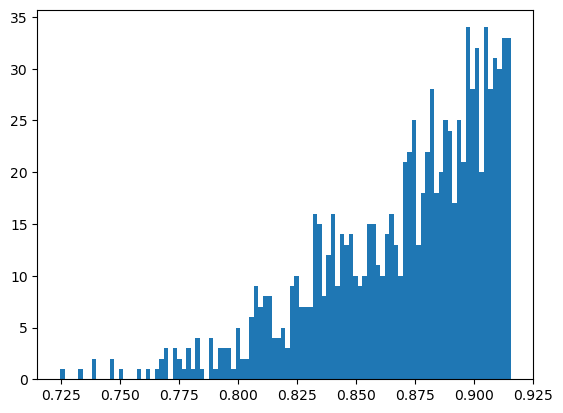

In [10]:
plt.hist(ord, bins=100)